# Evaluate Random Forest on Traditional Opcode N-gram Frequencies

Loads the traditional opcode n-gram Random Forest and its held-out sparse
test set, validates feature dimensions, and reports both in-sample
training-set and held-out test-set performance. `metrics.json` stores both
reports under explicit `training_set` and `test_set` keys. Train the model
notebook first for each n-gram size.


In [ ]:
# ---------------------------------------------------------------------------
# Cell 1: Setup, imports, configuration
# ---------------------------------------------------------------------------
import os
import gc
import glob
import json
import joblib
import numpy as np
import scipy.sparse as sp
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
    roc_curve,
    confusion_matrix,
)
from sklearn.model_selection import StratifiedKFold, cross_val_predict

# ---- Configuration ----
NGRAM_COUNT = 2  # set to the same n-gram size used for training
TRAIN_DIR = os.path.join("feature_datasets", f"{NGRAM_COUNT}gram", "train")
TEST_DIR = os.path.join("feature_datasets", f"{NGRAM_COUNT}gram", "test")    # directory holding X_batch_iii.npz / y_batch_iii.npy
OUTPUT_DIR = os.path.join("outputs", f"{NGRAM_COUNT}gram")
# Auto-detect chunk count from each split directory.
N_TRAIN_CHUNKS = len(glob.glob(os.path.join(TRAIN_DIR, "X_batch_*.npz")))
N_CHUNKS = len(glob.glob(os.path.join(TEST_DIR, "X_batch_*.npz")))
if N_TRAIN_CHUNKS == 0:
    raise FileNotFoundError(f"No X_batch_*.npz files found in {TRAIN_DIR}")
if N_CHUNKS == 0:
    raise FileNotFoundError(f"No X_batch_*.npz files found in {TEST_DIR}")

# Create the nested output directory if it doesn't already exist
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"NGRAM_COUNT = {NGRAM_COUNT}")
print(f"TRAIN_DIR   = {TRAIN_DIR}")
print(f"TEST_DIR    = {TEST_DIR}")
print(f"N_TRAIN_CHUNKS = {N_TRAIN_CHUNKS} (auto-detected)")
print(f"N_CHUNKS    = {N_CHUNKS} (auto-detected)")
print(f"OUTPUT_DIR  = {OUTPUT_DIR}")

NGRAM_COUNT = 3
TRAIN_DIR   = feature_datasets\3gram\train
TEST_DIR    = feature_datasets\3gram\test
N_TRAIN_CHUNKS = 36 (auto-detected)
N_CHUNKS    = 9 (auto-detected)
OUTPUT_DIR  = outputs\3gram


In [ ]:
# ---------------------------------------------------------------------------
# Cell 2: Load the trained model and load/stack the train and test chunks
# ---------------------------------------------------------------------------
def load_chunks(data_dir, n_chunks, prefix_features="X_batch", prefix_labels="y_batch"):
    """
    Memory-efficient loader for sparse feature chunks + label chunks.
    Mirrors the loader in TrainRandomForest.ipynb; kept local here so this
    notebook can be run standalone.

    Returns
    -------
    X : scipy.sparse.csr_matrix, shape (n_samples, n_features)
    y : np.ndarray, shape (n_samples,)
    """
    X_parts = []
    y_parts = []

    for i in range(n_chunks):
        x_path = os.path.join(data_dir, f"{prefix_features}_{i:03d}.npz")
        y_path = os.path.join(data_dir, f"{prefix_labels}_{i:03d}.npy")

        if not os.path.exists(x_path):
            raise FileNotFoundError(f"Missing feature chunk: {x_path}")
        if not os.path.exists(y_path):
            raise FileNotFoundError(f"Missing label chunk: {y_path}")

        X_chunk = sp.load_npz(x_path).tocsr()
        y_chunk = np.load(y_path)

        if X_chunk.shape[0] != y_chunk.shape[0]:
            raise ValueError(
                f"Row mismatch in chunk {i}: "
                f"X has {X_chunk.shape[0]} rows, y has {y_chunk.shape[0]} rows"
            )

        X_parts.append(X_chunk)
        y_parts.append(y_chunk)
        print(f"[{i + 1}/{n_chunks}] loaded {x_path}  shape={X_chunk.shape}")

        if (i + 1) % 6 == 0:
            gc.collect()

    print("Stacking chunks with scipy.sparse.vstack / np.concatenate ...")
    X = sp.vstack(X_parts, format="csr")
    y = np.concatenate(y_parts)
    del X_parts, y_parts
    gc.collect()

    print(f"Final stacked matrix: X.shape={X.shape}, y.shape={y.shape}")
    return X, y


# --- Load trained model ---
model_path = os.path.join(OUTPUT_DIR, "rf_model.joblib")
if not os.path.exists(model_path):
    raise FileNotFoundError(
        f"Trained model not found at {model_path}. Run TrainRandomForest.ipynb first."
    )

rf = joblib.load(model_path)
print(f"Loaded model from: {model_path}")
print(f"Model expects n_features_in_ = {rf.n_features_in_}")

# --- Load training data for out-of-fold threshold selection ---
X_train, y_train = load_chunks(TRAIN_DIR, N_TRAIN_CHUNKS)

# --- Load & stack held-out test chunks ---
X_test, y_true = load_chunks(TEST_DIR, N_CHUNKS)


Loaded model from: outputs\3gram\rf_model.joblib
Model expects n_features_in_ = 787060
[1/36] loaded feature_datasets\3gram\train\X_batch_000.npz  shape=(100, 787060)
[2/36] loaded feature_datasets\3gram\train\X_batch_001.npz  shape=(100, 787060)
[3/36] loaded feature_datasets\3gram\train\X_batch_002.npz  shape=(100, 787060)
[4/36] loaded feature_datasets\3gram\train\X_batch_003.npz  shape=(100, 787060)
[5/36] loaded feature_datasets\3gram\train\X_batch_004.npz  shape=(100, 787060)
[6/36] loaded feature_datasets\3gram\train\X_batch_005.npz  shape=(100, 787060)
[7/36] loaded feature_datasets\3gram\train\X_batch_006.npz  shape=(100, 787060)
[8/36] loaded feature_datasets\3gram\train\X_batch_007.npz  shape=(100, 787060)
[9/36] loaded feature_datasets\3gram\train\X_batch_008.npz  shape=(100, 787060)
[10/36] loaded feature_datasets\3gram\train\X_batch_009.npz  shape=(100, 787060)
[11/36] loaded feature_datasets\3gram\train\X_batch_010.npz  shape=(100, 787060)
[12/36] loaded feature_datasets

In [ ]:
# ---------------------------------------------------------------------------
# Cell 3: Sanity check - test feature dimensionality must match the model
# ---------------------------------------------------------------------------
assert X_test.shape[1] == rf.n_features_in_, (
    f"Feature mismatch: test data has {X_test.shape[1]} features, "
    f"but the model was trained on {rf.n_features_in_} features. "
    f"Check that NGRAM_COUNT ({NGRAM_COUNT}) matches the training run "
    f"that produced outputs/{NGRAM_COUNT}gram/rf_model.joblib."
)
print(
    "Feature dimension check passed: "
    f"X_test.shape[1] == rf.n_features_in_ == {rf.n_features_in_}"
)


Feature dimension check passed: X_test.shape[1] == rf.n_features_in_ == 787060


In [ ]:
# ---------------------------------------------------------------------------
# Cell 4: Tune threshold on training CV predictions, then evaluate held-out test
# ---------------------------------------------------------------------------
# Use stratified out-of-fold probabilities from training data to select the
# threshold. The held-out test set is not used for threshold selection.
positive_class_indices = np.flatnonzero(rf.classes_ == 1)
if positive_class_indices.size != 1:
    raise ValueError(f"Expected class label 1, found classes {rf.classes_}")
positive_class_index = int(positive_class_indices[0])

threshold_cv = StratifiedKFold(n_splits=3, shuffle=False)
print("Generating out-of-fold training probabilities for threshold selection ...")
oof_probabilities = cross_val_predict(
    rf,
    X_train,
    y_train,
    cv=threshold_cv,
    method="predict_proba",
    n_jobs=1,
)
oof_scores = oof_probabilities[:, positive_class_index]

# Select the class-1 threshold that maximizes F1 on the PR curve.
pr_precision, pr_recall, pr_thresholds = precision_recall_curve(
    y_train,
    oof_scores,
    pos_label=1,
)
if pr_thresholds.size == 0:
    raise ValueError("Could not derive threshold candidates from training CV scores")
pr_f1_scores = np.divide(
    2 * pr_precision[:-1] * pr_recall[:-1],
    pr_precision[:-1] + pr_recall[:-1],
    out=np.zeros_like(pr_thresholds, dtype=float),
    where=(pr_precision[:-1] + pr_recall[:-1]) > 0,
)
best_threshold_index = int(np.argmax(pr_f1_scores))
threshold_used = float(pr_thresholds[best_threshold_index])
threshold_cv_precision = float(pr_precision[best_threshold_index])
threshold_cv_recall = float(pr_recall[best_threshold_index])
threshold_cv_f1 = float(pr_f1_scores[best_threshold_index])
print(
    f"Selected threshold: {threshold_used:.6f} "
    f"(training OOF class-1 F1: {threshold_cv_f1:.6f})"
)

# Plot ROC and PR curves from the same out-of-fold training scores.
roc_fpr, roc_tpr, roc_thresholds = roc_curve(
    y_train,
    oof_scores,
    pos_label=1,
)
roc_marker_index = int(np.nanargmin(np.abs(roc_thresholds - threshold_used)))
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(roc_fpr, roc_tpr, label="Training OOF ROC")
axes[0].plot([0, 1], [0, 1], linestyle="--", color="gray", label="Chance")
axes[0].scatter(
    roc_fpr[roc_marker_index],
    roc_tpr[roc_marker_index],
    color="red",
    label=f"Selected threshold = {threshold_used:.4f}",
    zorder=3,
)
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("Training Out-of-Fold ROC Curve")
axes[0].legend()

axes[1].plot(pr_recall, pr_precision, label="Training OOF PR")
axes[1].scatter(
    threshold_cv_recall,
    threshold_cv_precision,
    color="red",
    label=f"Max class-1 F1, threshold = {threshold_used:.4f}",
    zorder=3,
)
axes[1].set_xlabel("Recall (class 1)")
axes[1].set_ylabel("Precision (class 1)")
axes[1].set_title("Training Out-of-Fold Precision-Recall Curve")
axes[1].legend()
fig.tight_layout()
plt.show()

# Evaluate the fitted model in-sample on the training data using the same
# CV-selected threshold that will be applied to the held-out test set.
train_y_proba = rf.predict_proba(X_train)[:, positive_class_index]
train_y_pred = (train_y_proba >= threshold_used).astype(int)
train_n_samples = int(y_train.shape[0])
train_acc = accuracy_score(y_train, train_y_pred)
train_tn, train_fp, train_fn, train_tp = confusion_matrix(
    y_train, train_y_pred, labels=[0, 1]
).ravel()
train_negative_count = train_tn + train_fp
if train_negative_count == 0:
    raise ValueError("Training false positive rate is undefined without class-0 samples")
train_false_positive_rate = train_fp / train_negative_count
train_report_dict = classification_report(y_train, train_y_pred, output_dict=True)
train_roc_auc = roc_auc_score(y_train, train_y_proba)
train_pr_auc = average_precision_score(y_train, train_y_proba)

# Release training/CV arrays before evaluating the held-out test split.
del X_train, y_train, oof_probabilities, oof_scores

y_proba = rf.predict_proba(X_test)[:, positive_class_index]
y_pred = (y_proba >= threshold_used).astype(int)

# --- Evaluation metrics (raw, 0-1 scale, full precision) ---
acc = accuracy_score(y_true, y_pred)
tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
negative_count = tn + fp
if negative_count == 0:
    raise ValueError("False positive rate is undefined because the test set has no class-0 samples")
false_positive_rate = fp / negative_count
report_dict = classification_report(y_true, y_pred, output_dict=True)
roc_auc = roc_auc_score(y_true, y_proba)
pr_auc = average_precision_score(y_true, y_proba)


def to_percent_report(report_dict, digits=4):
    """
    Convert a sklearn classification_report(output_dict=True) dict to a
    percentage scale (0-100), rounded to `digits` decimal places, for
    precision/recall/f1-score. 'support' is a raw sample count, not a
    rate, so it is left unrounded/unconverted.
    """
    percent_report = {}
    for key, val in report_dict.items():
        if isinstance(val, dict):
            # per-class rows and "macro avg" / "weighted avg" rows
            percent_report[key] = {
                "precision": round(val["precision"] * 100, digits),
                "recall": round(val["recall"] * 100, digits),
                "f1-score": round(val["f1-score"] * 100, digits),
                "support": val["support"],
            }
        else:
            # top-level "accuracy" scalar
            percent_report[key] = round(val * 100, digits)
    return percent_report


report_dict_percent = to_percent_report(report_dict)
train_report_dict_percent = to_percent_report(train_report_dict)

# --- Print threshold and percentage-formatted metrics ---
print(f"Threshold used for both datasets: {threshold_used:.6f}")
print("In-sample training-set performance (same samples used to fit the model):")
print(f"  Accuracy: {train_report_dict_percent['accuracy']:.4f}%")
print(f"  Weighted F1: {train_report_dict_percent['weighted avg']['f1-score']:.4f}%")
print("Held-out test-set performance:")
print(f"Accuracy: {report_dict_percent['accuracy']:.4f}%")
print(f"False positive rate (class 0): {false_positive_rate:.6f} ({false_positive_rate * 100:.4f}%)")
print(f"ROC-AUC: {roc_auc:.6f}")
print(f"PR-AUC: {pr_auc:.6f}")
print()
header = f"{'':<14}{'precision':>12}{'recall':>12}{'f1-score':>12}{'support':>10}"
print(header)
for label, vals in report_dict_percent.items():
    if label == "accuracy":
        continue
    row = (
        f"{label:<14}"
        f"{vals['precision']:>11.4f}%"
        f"{vals['recall']:>11.4f}%"
        f"{vals['f1-score']:>11.4f}%"
        f"{vals['support']:>10}"
    )
    print(row)

# --- a. Save predictions CSV ---
preds_df = pd.DataFrame({"y_true": y_true, "y_pred": y_pred})
preds_path = os.path.join(OUTPUT_DIR, "test_predictions.csv")
preds_df.to_csv(preds_path, index=False)
print(f"\nPredictions saved to: {preds_path}")

# --- b. Save metrics JSON ---
# Both datasets use the same threshold; training results are in-sample.
metrics = {
    "ngram_count": NGRAM_COUNT,
    "n_features": int(X_test.shape[1]),
    "threshold_selection": {
        "method": "max_class_1_f1_from_3_fold_training_oof_pr_curve",
        "threshold_used": threshold_used,
        "cv_folds": threshold_cv.n_splits,
        "cv_precision": threshold_cv_precision,
        "cv_recall": threshold_cv_recall,
        "cv_f1": threshold_cv_f1,
    },
    "training_set": {
        "evaluation_dataset": "training",
        "evaluation_type": "in_sample",
        "evaluation_note": "In-sample scores can be optimistic because these samples were used to fit the model.",
        "n_samples": train_n_samples,
        "n_features": int(rf.n_features_in_),
        "threshold_used": threshold_used,
        "accuracy": float(train_acc),
        "accuracy_percent": train_report_dict_percent["accuracy"],
        "false_positive_rate": float(train_false_positive_rate),
        "false_positive_rate_percent": float(train_false_positive_rate * 100),
        "true_negatives": int(train_tn),
        "false_positives": int(train_fp),
        "false_negatives": int(train_fn),
        "true_positives": int(train_tp),
        "roc_auc": float(train_roc_auc),
        "pr_auc": float(train_pr_auc),
        "classification_report": train_report_dict,
        "classification_report_percent": train_report_dict_percent,
    },
    "test_set": {
        "evaluation_dataset": "held_out_test",
        "evaluation_type": "held_out",
        "n_samples": int(X_test.shape[0]),
        "n_features": int(X_test.shape[1]),
        "threshold_used": threshold_used,
        "accuracy": float(acc),
        "accuracy_percent": report_dict_percent["accuracy"],
        "false_positive_rate": float(false_positive_rate),
        "false_positive_rate_percent": float(false_positive_rate * 100),
        "true_negatives": int(tn),
        "false_positives": int(fp),
        "false_negatives": int(fn),
        "true_positives": int(tp),
        "roc_auc": float(roc_auc),
        "pr_auc": float(pr_auc),
        "classification_report": report_dict,
        "classification_report_percent": report_dict_percent,
    },
}
metrics_path = os.path.join(OUTPUT_DIR, "metrics.json")
with open(metrics_path, "w") as f:
    json.dump(metrics, f, indent=2)
print(f"Metrics saved to: {metrics_path}")

# Cleanup
del X_test
gc.collect()


FileNotFoundError: [Errno 2] No such file or directory: 'outputs\\4gram\\test_predictions.csv'

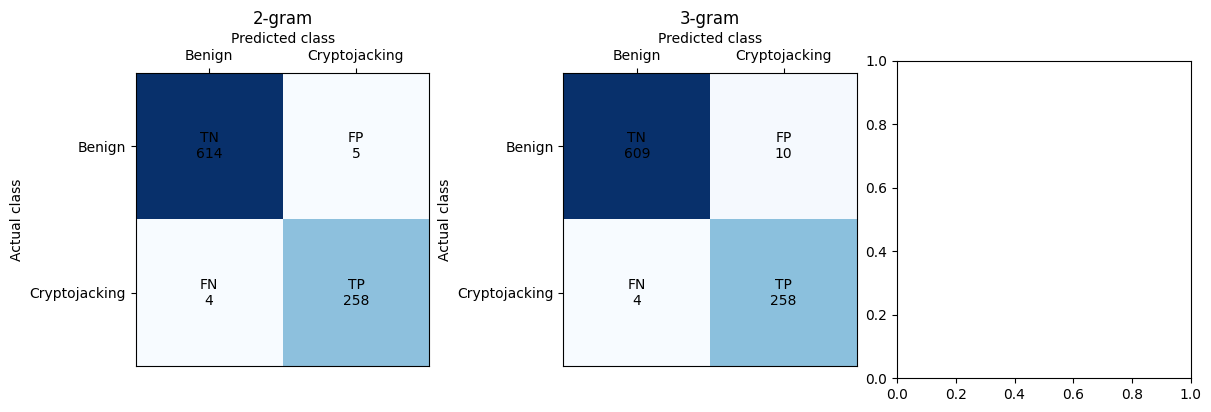

In [ ]:
from sklearn.metrics import confusion_matrix

ngram_counts = (2, 3, 4)
fig, axes = plt.subplots(1, 3, figsize=(12, 4), constrained_layout=True)
cell_labels = [["TN", "FP"], ["FN", "TP"]]

for ax, ngram in zip(axes, ngram_counts):
    predictions_path = os.path.join(
        "outputs", f"{ngram}gram", "test_predictions.csv"
    )
    predictions = pd.read_csv(predictions_path)
    cm = confusion_matrix(
        predictions["y_true"], predictions["y_pred"], labels=[0, 1]
    )

    image = ax.imshow(cm, cmap="Blues")
    ax.set(
        title=f"{ngram}-gram",
        xlabel="Predicted class",
        ylabel="Actual class",
        xticks=[0, 1],
        yticks=[0, 1],
        xticklabels=["Benign", "Cryptojacking"],
        yticklabels=["Benign", "Cryptojacking"],
    )
    ax.xaxis.set_label_position("top")
    ax.xaxis.tick_top()
    for row in range(2):
        for col in range(2):
            ax.text(
                col,
                row,
                f"{cell_labels[row][col]}\n{cm[row, col]:,}",
                ha="center",
                va="center",
            )

fig.colorbar(image, ax=axes, label="Count", shrink=0.8, pad=0.08)
fig.suptitle("Confusion Matrices by N-gram Model")
plt.show()

In [ ]:
ngram = 2
predictions_path = os.path.join("outputs", f"{ngram}gram", "test_predictions.csv")
predictions = pd.read_csv(predictions_path)

cm = confusion_matrix(
    predictions["y_true"],
    predictions["y_pred"],
    labels=[0, 1],
)

fig, ax = plt.subplots(figsize=(6, 5))
image = ax.imshow(cm, cmap="Blues")

ax.set(
    title=f"Confusion Matrix — Best Model ({ngram}-gram)",
    xlabel="Predicted class",
    ylabel="Actual class",
    xticks=[0, 1],
    yticks=[0, 1],
    xticklabels=["Benign", "Cryptojacking"],
    yticklabels=["Benign", "Cryptojacking"],
)
ax.xaxis.set_label_position("top")
ax.xaxis.tick_top()

cell_labels = [["TN", "FP"], ["FN", "TP"]]
for row in range(2):
    for col in range(2):
        ax.text(
            col,
            row,
            f"{cell_labels[row][col]}\n{cm[row, col]:,}",
            ha="center",
            va="center",
        )

fig.colorbar(image, ax=ax, label="Count")
fig.tight_layout()
plt.show()

In [ ]:
from sklearn.model_selection import learning_curve

ngram_counts = (2, 3, 4)
train_sizes = np.linspace(0.2, 1.0, 5)
learning_curve_cv = StratifiedKFold(n_splits=3, shuffle=False)

fig, ax = plt.subplots(figsize=(8, 5))

for ngram in ngram_counts:
    train_dir = os.path.join("feature_datasets", f"{ngram}gram", "train")
    output_dir = os.path.join("outputs", f"{ngram}gram")
    model_path = os.path.join(output_dir, "rf_model.joblib")
    n_chunks = len(glob.glob(os.path.join(train_dir, "X_batch_*.npz")))

    if n_chunks == 0:
        raise FileNotFoundError(f"No training feature chunks found in {train_dir}")
    if not os.path.exists(model_path):
        raise FileNotFoundError(f"Model not found: {model_path}")

    print(f"Loading learning-curve data from: {os.path.abspath(train_dir)}")
    X_curve, y_curve = load_chunks(train_dir, n_chunks)
    model_curve = joblib.load(model_path)

    sizes, train_scores, validation_scores = learning_curve(
        model_curve,
        X_curve,
        y_curve,
        train_sizes=train_sizes,
        cv=learning_curve_cv,
        scoring="f1",
        n_jobs=1,
    )

    mean_f1 = validation_scores.mean(axis=1)
    std_f1 = validation_scores.std(axis=1)
    mean_train_f1 = train_scores.mean(axis=1)
    label_values, label_counts = np.unique(y_curve, return_counts=True)
    label_distribution = dict(zip(label_values.tolist(), label_counts.tolist()))
    print(f"{ngram}-gram training data: {X_curve.shape}; labels: {label_distribution}")
    print(f"  training sizes: {sizes}")
    print(f"  CV validation F1 by size/fold:\n{np.round(validation_scores, 4)}")
    print(f"  mean training F1: {np.round(mean_train_f1, 4)}")
    ax.plot(sizes, mean_f1, marker="o", label=f"{ngram}-gram CV validation")
    ax.fill_between(sizes, mean_f1 - std_f1, mean_f1 + std_f1, alpha=0.15)

    del X_curve, y_curve, model_curve
    gc.collect()

ax.set(
    xlabel="Number of training samples",
    ylabel="3-fold CV validation F1-score (class 1)",
    title="Random Forest Learning Curves by N-gram Size",
    ylim=(0, 1.05),
)
ax.grid(True, alpha=0.3)
ax.legend(title="N-gram size")
fig.tight_layout()
plt.show()